# Opgave 1

Gegeven is de volgende constructie:

```{figure} ./opgave1_data/constructie.svg
:align: center
:source: https://github.com/Structural-Mechanics-CEG/mechanics-figures-source/tree/main/sympy_4
:number:
```

Vind het maximale moment en de maximale doorzakking, inclusief de locaties van deze maxima. Gebruik SymPy om dit probleem op te lossen. Maak de opdracht in [WebLab](https://weblab.tudelft.nl/ctb1310/2025-2026/assignment/166886/info). Heb je nog geen toegang? Schrijf je dan eerst [hier](https://weblab.tudelft.nl/ctb1310/2025-2026/enroll) in voor dit vak op WebLab.

::::{question} Opgave
:type: short-answer
:variant: blocks
:admonition:
:class: exercise
:nocaption:

---
M[60] Wat is het maximale moment in $\rm{kNm}$?
M[4] Waar treedt deze op in de $x = ... \, \left[\rm{m}\right]$?
---

::::

::::{question} Opgave
:type: short-answer
:variant: blocks
:admonition:
:class: exercise
:nocaption:

---
MRP[16.2288;0.025] Wat is de maximale doorzakking in $\rm{mm}$?
MRP[ 4.3485;0.025] Waar treedt deze op in de $x = ... \, \left[\rm{m}\right]$?
---

::::

::::{admonition-start} Uitwerking
:class: solution, dropdown
::::

In [115]:
import sympy as sym
sym.init_printing(use_latex='mathjax')
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display, Math

%config InlineBackend.figure_formats = ['svg']

def display(*objs):
    for obj in objs:
        if isinstance(obj, dict):
            lines = [f"{sym.latex(k)} &= {sym.latex(obj[k])}" for k in sorted(obj, key=lambda s: str(s))]
            ipy_display(Math(r"\begin{aligned}" + r"\\ ".join(lines) + r"\end{aligned}"))
        else:
            ipy_display(obj)

def plot(w_list, x_range_list,ylabel):
    fig = plt.figure(facecolor='none')
    for i, w in enumerate(w_list):
        # check if x is the only symbol in the expression
        if len(w.free_symbols) > 1:
            raise ValueError('The expression must be a function of x only.')
        
        w_numpy = sym.lambdify(x, w)
        x_vals = np.linspace(x_range_list[i][0], x_range_list[i][1], 100)
        
        # if the expression is a constant, we need to make sure that it is broadcasted correctly
        if isinstance(w_numpy(x_vals),float) or isinstance(w_numpy(x_vals),int):
            w_numpy = np.vectorize(w_numpy)
            plt.plot([x_range_list[i][0], x_range_list[i][1]],[w_numpy(x_vals),w_numpy(x_vals)])
        else:
            plt.plot(x_vals,w_numpy(x_vals))

        plt.xlabel('$x$')
        plt.ylabel(ylabel)
    ax = plt.gca()
    ax.set_facecolor('none')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.invert_yaxis()

In [116]:
import sympy as sym

In [125]:
sym.var('x')
sym.var('C1, C2, C3, C4, C5, C6, C7, C8');

In [ ]:
q1 = 0
q2 = 0

In [127]:
V1 = sym.integrate(-q1,x)+C1
M1 = sym.integrate(V1,x)+C2
kappa1 = M1 / 3000
phi1 = sym.integrate(kappa1,x)+C3
w1 = sym.integrate(-phi1,x)+C4

V2 = sym.integrate(-q2,x)+C5
M2 = sym.integrate(V2,x)+C6
kappa2 = M2 / 1500
phi2 = sym.integrate(kappa2,x)+C7
w2 = sym.integrate(-phi2,x)+C8

In [128]:
Eq1  = sym.Eq(  w1.subs(x, 0), 0)
Eq2  = sym.Eq(  M1.subs(x, 0), 0)
Eq3  = sym.Eq(  w1.subs(x, 4),   w2.subs(x, 4))
Eq4  = sym.Eq(  V1.subs(x, 4),   V2.subs(x, 4) + 30)
Eq5  = sym.Eq(  M1.subs(x, 4),   M2.subs(x, 4))
Eq6  = sym.Eq(phi1.subs(x, 4), phi2.subs(x, 4))
Eq7  = sym.Eq(  w2.subs(x, 8), 0)
Eq8  = sym.Eq(  M2.subs(x, 8), 0)

In [129]:
sol = sym.solve((Eq1, Eq2, Eq3, Eq4, Eq5, Eq6, Eq7, Eq8), (C1, C2, C3, C4, C5, C6, C7, C8))
display(sol)

<IPython.core.display.Math object>

In [130]:
w1_oplossing = w1.subs(sol)
w2_oplossing = w2.subs(sol)
phi1_oplossing = phi1.subs(sol)
phi2_oplossing = phi2.subs(sol)
V1_oplossing = V1.subs(sol)
V2_oplossing = V2.subs(sol)
M1_oplossing = M1.subs(sol)
M2_oplossing = M2.subs(sol)

   2            
  x     2⋅x   19
- ─── + ─── - ──
  200   25    75

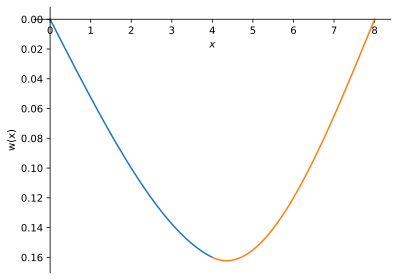

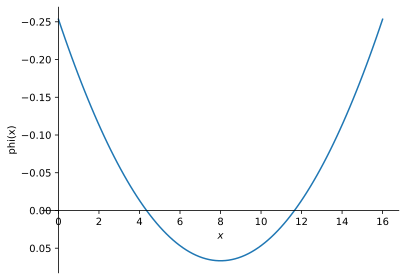

In [133]:
plot([w1_oplossing, w2_oplossing], [(0, 4), (4, 8)], 'w(x)')
plot([phi2_oplossing], [(0, 16)], 'phi(x)')
display(phi2_oplossing)

In [138]:
eq9 = sym.Eq(phi2_oplossing, 0)
max_buiging_x = sym.solve(eq9, x)[0] # m
display(max_buiging_x)
display(max_buiging_x.evalf())
max_buiging = w2_oplossing.subs(x, max_buiging_x)*100 # mm
display((max_buiging).simplify())
display((max_buiging).evalf())

    2⋅√30
8 - ─────
      3  

4.34851628329889

80⋅√30
──────
  27  

16.2288165186716

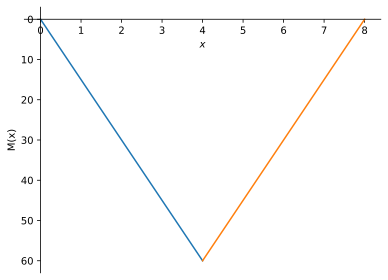

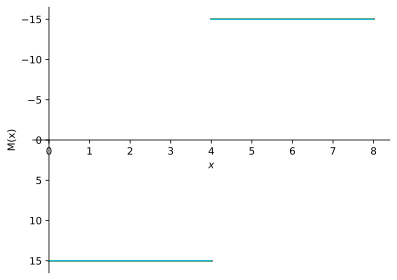

In [ ]:
plot([M1_oplossing, M2_oplossing], [(0, 4), (4, 8)], 'M(x)')
plot([V1_oplossing, V2_oplossing], [(0, 4), (4, 8)], 'M(x)')

In [139]:
max_moment_x = 4 # m
max_moment = M1_oplossing.subs(x, max_moment_x) # kNm
display(max_moment)

60

::::{admonition-end}
::::